# Cleaning & EDA — full PRCA cohort (File A/B/C)

This notebook loads the **private** Prolific + Qualtrics exports from the sibling data folder (never committed):

```text
../sibling_data/PRCAProlificExport_FileA.csv
../sibling_data/PRCAProlificExport_FileB.csv
../sibling_data/PRCAQualtricsExport_FileC.csv
```

It cleans to an analytic sample, scores ground-truth PRCA subscales, and produces EDA tables that map onto the research questions:

1. **RQ1 — Employment:** does employment status improve CA prediction over demographics alone?
2. **RQ2 — Transit:** does transportation-use data improve prediction / get used sensibly?
3. **RQ3 — Combined:** does employment + transit help beyond either alone, or are cues redundant?
4. **Main RQ — Stereotyping:** does LLM prediction error cluster by demographic group?


In [11]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from ca_personas.eda import run_eda
from ca_personas.load import load_full_cohort
from ca_personas.paths import (
    DEFAULT_PROLIFIC_A,
    DEFAULT_PROLIFIC_B,
    DEFAULT_QUALTRICS_C,
    sibling_data_available,
)

pd.set_option("display.max_columns", 40)
print("sibling_data available:", sibling_data_available())
print(DEFAULT_PROLIFIC_A)
print(DEFAULT_PROLIFIC_B)
print(DEFAULT_QUALTRICS_C)
assert sibling_data_available(), (
    "Place File A/B/C under ../sibling_data/ before running this notebook."
)


sibling_data available: True
/Users/morningstar/Desktop/Cold_Storage/sibling_data/PRCAProlificExport_FileA.csv
/Users/morningstar/Desktop/Cold_Storage/sibling_data/PRCAProlificExport_FileB.csv
/Users/morningstar/Desktop/Cold_Storage/sibling_data/PRCAQualtricsExport_FileC.csv


## Load → join → clean → score

- Stack Prolific File A + File B (two recruitment waves, same schema)
- Join to Qualtrics File C on `Q0` ↔ `Participant id`
- Keep inner-join rows with complete PRCA group (`Q1–Q6`) + interpersonal (`Q13–Q18`) items
- Flag employment / transit coverage for the tiered research contrasts


In [12]:
participants, cleaning_report = load_full_cohort(join_how="inner")
print(json.dumps(cleaning_report, indent=2))
participants.head()


{
  "n_prolific_raw": 262,
  "n_prolific_unique": 262,
  "n_qualtrics_raw": 273,
  "n_qualtrics_with_pid": 255,
  "n_qualtrics_complete_ca": 260,
  "n_joined": 252,
  "n_matched_both": 252,
  "n_analytic": 241,
  "n_dropped_missing_pid": 0,
  "n_dropped_incomplete_ca": 11,
  "n_dropped_unscorable_ca": 0,
  "n_dropped_unjoined": 31,
  "n_prolific_only": 10,
  "n_qualtrics_only": 21,
  "n_qualtrics_missing_pid": 18,
  "waves": {
    "B": 153,
    "A": 99
  },
  "notes": [
    "Normalized 19 DATA_EXPIRED Student status values to missing.",
    "Full Prolific waves (File A/B) omit Ethnicity / Nationality / Language; demos tier uses Age, Sex, Country of residence, and Student status.",
    "Analytic sample = Prolific\u2229Qualtrics with complete scorable PRCA group + interpersonal items.",
    "Merge coverage (pre-CA filter): 252 matched Prolific\u2229Qualtrics; 21 Qualtrics-only (incl. 18 blank Q0 test rows; disregard); 10 Prolific-only (disregard)."
  ]
}


,participant_id,Age,Sex,Country of residence,Student status,Employment status,Submission id,Started at,Completed at,Time taken,Total approvals,prolific_wave,ResponseId,LocationLatitude,LocationLongitude,Duration (in seconds),StartDate,EndDate,Q0,Q1,...,Q15,Q16,Q17,Q18,Q26,Q27,Q28,Q29,Q20,Q21,Q18_advice,Q19,has_employment_info,has_transit_info,has_employment_and_transit,has_core_demos,gt_group_ca,gt_interpersonal_ca,gt_group_band,gt_interpersonal_band
0,ebab12e9878344fdc93a8c1cad27ff2f709e12b90f0496...,36.0,Male,United States,Yes,Part-Time,c4ab54135f26292de9faf6a1043ba0817e8c2fb29cd050...,2025,2025,188.0,700+,A,8b2aab2671fd48447585f0ceda69225e04532834db2565...,33.4158,-119.0493,165,2025,2025,ebab12e9878344fdc93a8c1cad27ff2f709e12b90f0496...,Neither agree nor disagree,...,Neither agree nor disagree,Somewhat agree,Somewhat agree,Somewhat agree,2-4 days a month,3-4 rides in a typical day,0-1 days a month,3-4 rides in a typical day,NaN,NaN,NaN,NaN,True,True,True,True,14,16,moderate,moderate
1,b6954799ca47bc836ac02ab86e4710c3b0e096d7ace449...,41.0,Male,United States,No,Other,91d238c88316a444585278049cc9bdedb871414ebdb0dd...,2025,2025,110.0,700+,A,66a2ee6c4d2f7cb02f5901319dacabfc1977e1639dce60...,34.7196,-81.5487,68,2025,2025,b6954799ca47bc836ac02ab86e4710c3b0e096d7ace449...,Neither agree nor disagree,...,Neither agree nor disagree,Neither agree nor disagree,Neither agree nor disagree,Somewhat disagree,Never,1-2 rides in a typical day,0-1 days a month,1-2 rides in a typical day,NaN,NaN,NaN,NaN,True,True,True,True,17,17,moderate,moderate
2,6ac07c3845b0ce5cac4ab3569ea70236b7cfa8fd51576e...,39.0,Male,United States,No,Full-Time,f3943bf594d541b81fbde88288600739a47ee97b0524c1...,2025,2025,63.0,700+,A,1cab4557741ee763d960a629350156b8590462a6d6188b...,36.7595,-95.2947,36,2025,2025,6ac07c3845b0ce5cac4ab3569ea70236b7cfa8fd51576e...,Somewhat disagree,...,Somewhat disagree,Somewhat agree,Somewhat agree,Somewhat disagree,Never,1-2 rides in a typical day,Never,1-2 rides in a typical day,NaN,NaN,NaN,NaN,True,True,True,True,11,12,low,low
3,c67b3266ecd4af12979c1f67d1efffd0d3e9bfbc567d21...,61.0,Male,United Kingdom,No,Other,0799215a062ddef149fa49bfe069e3ff2b4b79f08f5b01...,2025,2025,85.0,700+,A,7bbf0ccfea1454bac9a4d4ffa0d079dbff840fefad510d...,51.9759,-1.8685,74,2025,2025,c67b3266ecd4af12979c1f67d1efffd0d3e9bfbc567d21...,Neither agree nor disagree,...,Strongly disagree,Strongly agree,Strongly agree,Strongly disagree,Never,1-2 rides in a typical day,Never,1-2 rides in a typical day,NaN,NaN,NaN,NaN,True,True,True,True,10,6,low,low
4,1cefb8d34b92489e8ffd9cf34c469964f0527b1cae33e0...,45.0,Male,United States,No,Full-Time,f49783f27606316e1e3a590e7403eab417b5612c2faeaf...,2025,2025,142.0,700+,A,d6363c1da690391ed0eee4cef9991675da95bb61125424...,36.8237,-81.2130,117,2025,2025,1cefb8d34b92489e8ffd9cf34c469964f0527b1cae33e0...,Strongly disagree,...,Somewhat disagree,Strongly agree,Somewhat agree,Strongly disagree,Never,1-2 rides in a typical day,2-4 days a month,1-2 rides in a typical day,NaN,NaN,NaN,NaN,True,True,True,True,8,12,low,low


In [13]:
# Research-covariate coverage (supports RQ1–RQ3 sample support)
coverage = participants[
    ["has_core_demos", "has_employment_info", "has_transit_info", "has_employment_and_transit"]
].mean().rename("share").to_frame()
coverage


,share
has_core_demos,0.929461
has_employment_info,1.000000
has_transit_info,1.000000
has_employment_and_transit,1.000000


## Ground-truth CA distributions

Targets for every persona tier and ML baseline: group + interpersonal PRCA subscales (6–30).


In [14]:
gt_summary = participants[["gt_group_ca", "gt_interpersonal_ca"]].describe().T
gt_summary


,count,mean,std,min,25%,50%,75%,max
gt_group_ca,241.0,14.622407,6.032771,6.0,10.0,13.0,18.0,30.0
gt_interpersonal_ca,241.0,14.311203,5.817953,6.0,10.0,13.0,18.0,30.0


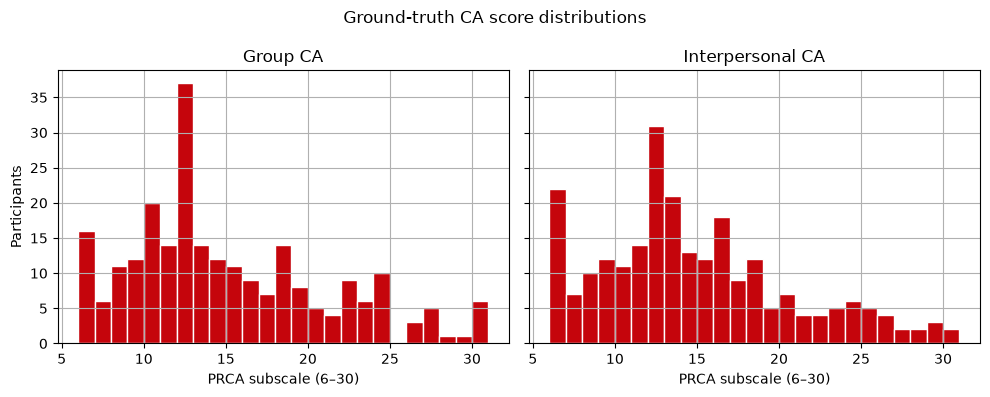

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, col, title in zip(
    axes,
    ["gt_group_ca", "gt_interpersonal_ca"],
    ["Group CA", "Interpersonal CA"],
):
    participants[col].hist(ax=ax, bins=range(6, 32), color="#C5050C", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("PRCA subscale (6–30)")
axes[0].set_ylabel("Participants")
fig.suptitle("Ground-truth CA score distributions")
fig.tight_layout()
plt.show()


## RQ1 lens — CA by employment status

If an LLM stereotypes “unemployed → higher CA,” residual error should later be checked against these empirical means.


In [16]:
by_emp = (
    participants.groupby("Employment status", dropna=False)
    .agg(
        n=("participant_id", "count"),
        mean_group=("gt_group_ca", "mean"),
        mean_interpersonal=("gt_interpersonal_ca", "mean"),
        pct_high_group=("gt_group_band", lambda s: (s == "high").mean()),
    )
    .reset_index()
)
by_emp


,Employment status,n,mean_group,mean_interpersonal,pct_high_group
0,Full-Time,148,13.324324,12.993243,0.128378
1,Other,62,16.951613,16.564516,0.370968
2,Part-Time,31,16.161290,16.096774,0.258065


## RQ2 lens — CA by public-transit use (Q26)

Transit items feed the `transit` persona tier. Sparse `Q20`/`Q21` (license/car) is expected in File C; frequency items `Q26–Q29` are the primary signal.


In [17]:
by_transit = (
    participants.groupby("Q26", dropna=False)
    .agg(
        n=("participant_id", "count"),
        mean_group=("gt_group_ca", "mean"),
        mean_interpersonal=("gt_interpersonal_ca", "mean"),
    )
    .reset_index()
    .sort_values("n", ascending=False)
)
by_transit


,Q26,n,mean_group,mean_interpersonal
3,8 or more days a month,55,12.836364,13.163636
1,2-4 days a month,53,14.509434,13.716981
4,Never,50,17.380000,16.340000
2,4-8 days a month,46,13.282609,13.478261
0,0-1 days a month,37,15.378378,15.162162


## RQ3 lens — employment × transit contingency

If employment and transit use are strongly associated in this sample, Tier 3 may not beat Tier 1 or 2 alone.


In [18]:
xtab = pd.crosstab(
    participants["Employment status"].fillna("(missing)"),
    participants["Q26"].fillna("(missing)"),
    margins=True,
)
xtab


Q26,0-1 days a month,2-4 days a month,4-8 days a month,8 or more days a month,Never,All
Employment status,,,,,,
Full-Time,26,33,32,35,22,148
Other,6,16,7,12,21,62
Part-Time,5,4,7,8,7,31
All,37,53,46,55,50,241


## Stereotyping lens — CA by sex and country

Demographic slices used later when correlating LLM absolute error with group membership.


In [19]:
for col in ("Sex", "Country of residence", "Student status"):
    print("\n===", col, "===")
    display(
        participants.groupby(col, dropna=False)
        .agg(
            n=("participant_id", "count"),
            mean_group=("gt_group_ca", "mean"),
            mean_interpersonal=("gt_interpersonal_ca", "mean"),
        )
        .reset_index()
    )



=== Sex ===


,Sex,n,mean_group,mean_interpersonal
0,Female,120,14.875000,14.750000
1,Male,121,14.371901,13.876033



=== Country of residence ===


,Country of residence,n,mean_group,mean_interpersonal
0,Canada,20,14.650000,15.150000
1,France,1,30.000000,26.000000
2,Hungary,1,6.000000,9.000000
3,India,1,8.000000,6.000000
4,Ireland,2,11.500000,8.500000
5,New Zealand,1,15.000000,13.000000
6,Spain,1,16.000000,9.000000
7,United Kingdom,56,16.339286,15.535714
8,United States,158,14.037975,13.898734



=== Student status ===


,Student status,n,mean_group,mean_interpersonal
0,No,190,14.257895,13.773684
1,Yes,34,16.352941,17.029412
2,NaN,17,15.235294,14.882353


## Write EDA artifacts

Artifacts land in `outputs/eda/` (gitignored) and `data/processed/` for the prediction pipeline.


In [20]:
out = ROOT / "outputs" / "eda"
processed = ROOT / "data" / "processed"
processed.mkdir(parents=True, exist_ok=True)
participants.to_csv(processed / "participants_scored.csv", index=False)
(processed / "cleaning_report.json").write_text(json.dumps(cleaning_report, indent=2))
artifacts = run_eda(participants, out, cleaning_report=cleaning_report)
artifacts


{'ca_score_summary': PosixPath('/Users/morningstar/Desktop/Cold_Storage/psych755-jjb/outputs/eda/ca_score_summary.csv'),
 'ca_by_group': PosixPath('/Users/morningstar/Desktop/Cold_Storage/psych755-jjb/outputs/eda/ca_by_group.csv'),
 'employment_by_transit': PosixPath('/Users/morningstar/Desktop/Cold_Storage/psych755-jjb/outputs/eda/employment_by_transit_q26.csv'),
 'missingness': PosixPath('/Users/morningstar/Desktop/Cold_Storage/psych755-jjb/outputs/eda/missingness.csv'),
 'research_alignment': PosixPath('/Users/morningstar/Desktop/Cold_Storage/psych755-jjb/outputs/eda/research_alignment.json')}